<a href="https://colab.research.google.com/github/miriam-silva/testesp2icoma/blob/main/prova_02_miriam_silva.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Prova 01:** IBM | Direção Diária:
**Aluna:** Miriam Silva Corrêa



# Pipeline 1 | Extração de Dados [Fase 1]

## Bibliotecas

In [494]:
import requests
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

## Consumo da API (Alpha Vantage)

In [495]:
API_KEY = 'XBWDB57V8PK8DW8W'
symbol = 'IBM'
url = f'https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol=IBM&apikey={API_KEY}&outputsize=compact'
response = requests.get(url)
data = response.json()

## Transformação para DataFrame

In [496]:
if 'Time Series (Daily)' in data:
  df = pd.DataFrame.from_dict(data['Time Series (Daily)'], orient='index')
  df.columns = ['open', 'high', 'low', 'close', 'volume']
  df = df.astype(float)
  df.index = pd.to_datetime(df.index)
  df = df.sort_index()
  print("Dados carregados com sucesso!")
else:
  print("Erro na API:", data)

Dados carregados com sucesso!


In [497]:
df.head()

,open,high,low,close,volume
2026-01-26,293.16,296.815,293.1400,296.33,3726890.0
2026-01-27,297.16,297.330,293.2700,293.86,2944722.0
2026-01-28,294.17,295.950,291.2601,294.16,5790347.0
2026-01-29,317.86,319.900,303.4700,309.24,10124929.0
2026-01-30,307.60,307.783,299.7300,306.70,5940669.0


# Pipeline 2 | Laborização (Feature Engineering) [Fase 2]

## Criação da Variável Alvo (Y)

In [498]:
df['target'] = (df['close'] > df['open']).astype(int)

## Criação de Preditores (X) baseados em Lags

In [499]:
df['variation'] = (df['close'] - df['open']) / df['open']
df['prev_variation'] = df['variation'].shift(1)
df['prev_variation_2'] = df['variation'].shift(2)
df['prev_variation_3'] = df['variation'].shift(3)
df['volume_log'] = np.log1p(df['volume'])

df['prev_volume'] = df['volume_log'].shift(1)
df['prev_volume_2'] = df['volume_log'].shift(2)

df_final = df[['prev_variation', 'prev_variation_2', 'prev_variation_3', 'prev_volume', 'prev_volume_2', 'target']].dropna()

print("Colunas extras removidas e valores nulos excluídos.")
df_final.head()

Colunas extras removidas e valores nulos excluídos.


,prev_variation,prev_variation_2,prev_variation_3,prev_volume,prev_volume_2,target
2026-01-29,-0.000034,-0.011105,0.010813,15.571703,14.895525,0
2026-01-30,-0.027119,-0.000034,-0.011105,16.130511,15.571703,0
2026-02-02,-0.002926,-0.027119,-0.000034,15.597332,16.130511,1
2026-02-03,0.023479,-0.002926,-0.027119,15.337469,15.597332,0
2026-02-04,-0.057907,0.023479,-0.002926,16.239961,15.337469,0


# Pipeline 3 | Tratamento e Normalização [Fase 3]

In [500]:
df_final.head()

,prev_variation,prev_variation_2,prev_variation_3,prev_volume,prev_volume_2,target
2026-01-29,-0.000034,-0.011105,0.010813,15.571703,14.895525,0
2026-01-30,-0.027119,-0.000034,-0.011105,16.130511,15.571703,0
2026-02-02,-0.002926,-0.027119,-0.000034,15.597332,16.130511,1
2026-02-03,0.023479,-0.002926,-0.027119,15.337469,15.597332,0
2026-02-04,-0.057907,0.023479,-0.002926,16.239961,15.337469,0


## Verificação de valores nulos

In [501]:
df_final.isnull().sum()

,0
prev_variation,0
prev_variation_2,0
prev_variation_3,0
prev_volume,0
prev_volume_2,0
target,0


## Estatísticas descritivas

In [502]:
df_final.describe()

,prev_variation,prev_variation_2,prev_variation_3,prev_volume,prev_volume_2,target
count,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000
mean,-0.001980,-0.002092,-0.001856,15.697479,15.692192,0.474227
std,0.025717,0.025733,0.025745,0.499245,0.505020,0.501929
min,-0.121948,-0.121948,-0.121948,14.672507,14.672507,0.000000
25%,-0.012082,-0.012082,-0.011105,15.387766,15.378166,0.000000
50%,-0.001019,-0.002313,-0.001019,15.585256,15.585256,0.000000
75%,0.009595,0.009595,0.010526,15.939114,15.939114,1.000000
max,0.087669,0.087669,0.087669,17.308381,17.308381,1.000000


## Remoção de Outliers

In [503]:
df_final = df_final[
    (np.abs(df_final['prev_variation']) < 3 * df_final['prev_variation'].std()) &
    (np.abs(df_final['prev_variation_2']) < 3 * df_final['prev_variation_2'].std()) &
    (np.abs(df_final['prev_variation_3']) < 3 * df_final['prev_variation_3'].std())
]

## Seleção de Variáveis (X e y)

In [504]:
X = df_final[['prev_variation', 'prev_variation_2', 'prev_variation_3', 'prev_volume', 'prev_volume_2']]
y = df_final['target']

## Análise de Balanceamento das Classes

In [505]:
print(y.value_counts())

target
0    49
1    42
Name: count, dtype: int64


## Divisão Treino/Teste

In [506]:
tamanho = int(len(X)*0.9)

X_train = X[:tamanho]
X_test = X[tamanho:]

y_train = y[:tamanho]
y_test = y[tamanho:]

## Normalização (StandardScaler)

In [507]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Pipeline 4 | Decision Tree [Fase 4]

In [508]:
arvore_ibm = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=0)
arvore_ibm.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=0)

In [509]:
previsoes_arvore = arvore_ibm.predict(X_test)

In [510]:
previsoes_arvore

array([1, 1, 0, 1, 1, 1, 0, 1, 1, 1])

In [511]:
accuracy_score(y_test, previsoes_arvore)

0.3

In [512]:
confusion_matrix(y_test, previsoes_arvore)

array([[2, 7],
       [0, 1]])

In [513]:
print(classification_report(y_test, previsoes_arvore))

              precision    recall  f1-score   support

           0       1.00      0.22      0.36         9
           1       0.12      1.00      0.22         1

    accuracy                           0.30        10
   macro avg       0.56      0.61      0.29        10
weighted avg       0.91      0.30      0.35        10



# Pipeline 5 | Modelagem por Random Forest [Fase 5]

In [514]:
random_ibm = RandomForestClassifier(n_estimators=100, criterion='entropy', max_depth=5, random_state=0)
random_ibm.fit(X_train, y_train)
random_ibm

RandomForestClassifier(criterion='entropy', max_depth=5, random_state=0)

In [515]:
previsoes_random = random_ibm.predict(X_test)

In [516]:
previsoes_random

array([1, 1, 1, 0, 1, 1, 0, 1, 0, 1])

In [517]:
accuracy_score(y_test, previsoes_random)

0.4

In [518]:
confusion_matrix(y_test, previsoes_random)

array([[3, 6],
       [0, 1]])

In [519]:
print(classification_report(y_test, previsoes_random))

              precision    recall  f1-score   support

           0       1.00      0.33      0.50         9
           1       0.14      1.00      0.25         1

    accuracy                           0.40        10
   macro avg       0.57      0.67      0.38        10
weighted avg       0.91      0.40      0.47        10



# Pipeline 6 | SVM [Fase 6]

In [520]:
svm_ibm = SVC(kernel='rbf', C=2.0, random_state=1)
svm_ibm.fit(X_train, y_train)
svm_ibm

SVC(C=2.0, random_state=1)

In [521]:
svm_previsoes = svm_ibm.predict(X_test)
svm_previsoes

array([0, 1, 1, 1, 1, 1, 1, 1, 0, 1])

In [522]:
accuracy_score(y_test, svm_previsoes)

0.3

In [523]:
confusion_matrix(y_test, svm_previsoes)

array([[2, 7],
       [0, 1]])

In [524]:
print(classification_report(y_test, svm_previsoes))

              precision    recall  f1-score   support

           0       1.00      0.22      0.36         9
           1       0.12      1.00      0.22         1

    accuracy                           0.30        10
   macro avg       0.56      0.61      0.29        10
weighted avg       0.91      0.30      0.35        10



# Pipeline 7 | Redes Neurais [Fase 7 - IBM Base]

In [525]:
redeneural_ibm = MLPClassifier(verbose=True, max_iter=1000, tol=0.000010, solver='adam', hidden_layer_sizes=(100), activation='relu')
redeneural_ibm.fit(X_train, y_train)
redeneural_ibm

Iteration 1, loss = 0.71080860
Iteration 2, loss = 0.70756259
Iteration 3, loss = 0.70439952
Iteration 4, loss = 0.70132203
Iteration 5, loss = 0.69833739
Iteration 6, loss = 0.69544743
Iteration 7, loss = 0.69264491
Iteration 8, loss = 0.68993702
Iteration 9, loss = 0.68730674
Iteration 10, loss = 0.68476478
Iteration 11, loss = 0.68230288
Iteration 12, loss = 0.67991645
Iteration 13, loss = 0.67759218
Iteration 14, loss = 0.67534601
Iteration 15, loss = 0.67315965
Iteration 16, loss = 0.67103981
Iteration 17, loss = 0.66897427
Iteration 18, loss = 0.66695861
Iteration 19, loss = 0.66498376
Iteration 20, loss = 0.66303878
Iteration 21, loss = 0.66114973
Iteration 22, loss = 0.65931612
Iteration 23, loss = 0.65753079
Iteration 24, loss = 0.65578643
Iteration 25, loss = 0.65407595
Iteration 26, loss = 0.65241581
Iteration 27, loss = 0.65080916
Iteration 28, loss = 0.64923273
Iteration 29, loss = 0.64767088
Iteration 30, loss = 0.64611785
Iteration 31, loss = 0.64459442
Iteration 32, los

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=100, max_iter=1000, tol=1e-05, verbose=True)

In [526]:
redeneural_ibm.out_activation_

'logistic'

In [527]:
previsoes_redeneural = redeneural_ibm.predict(X_test)
previsoes_redeneural

array([0, 0, 0, 1, 1, 1, 0, 0, 0, 1])

In [528]:
accuracy_score(y_test, previsoes_redeneural)

0.7

In [529]:
confusion_matrix(y_test, previsoes_redeneural)

array([[6, 3],
       [0, 1]])

In [530]:
print(classification_report(y_test, previsoes_redeneural))

              precision    recall  f1-score   support

           0       1.00      0.67      0.80         9
           1       0.25      1.00      0.40         1

    accuracy                           0.70        10
   macro avg       0.62      0.83      0.60        10
weighted avg       0.93      0.70      0.76        10



# Pipeline 8 | KNN [Fase 8 - IBM Base]

In [531]:
parametros = {'n_neighbors': [3, 5, 10, 20], 'p': [1, 2]}

In [532]:
grid_ibm = GridSearchCV(estimator=KNeighborsClassifier(), param_grid=parametros)
grid_ibm.fit(X_train, y_train)

GridSearchCV(estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [3, 5, 10, 20], 'p': [1, 2]})

In [533]:
melhor_parametros_ibm = grid_ibm.best_params_
melhor_resultado_ibm = grid_ibm.best_score_

In [534]:
print(melhor_parametros_ibm)
print(melhor_resultado_ibm)

{'n_neighbors': 20, 'p': 1}
0.5426470588235295


In [535]:
knn_ibm = KNeighborsClassifier(n_neighbors=melhor_parametros_ibm['n_neighbors'], p=melhor_parametros_ibm['p'])
knn_ibm.fit(X_train, y_train)
knn_ibm

KNeighborsClassifier(n_neighbors=20, p=1)

In [536]:
previsoes_knn = knn_ibm.predict(X_test)

In [537]:
previsoes_knn

array([1, 0, 1, 1, 1, 1, 1, 0, 0, 1])

In [538]:
accuracy_score(y_test, previsoes_knn)

0.4

In [539]:
confusion_matrix(y_test, previsoes_knn)

array([[3, 6],
       [0, 1]])

In [540]:
confusion_matrix(y_test, previsoes_knn)

array([[3, 6],
       [0, 1]])

In [541]:
print(classification_report(y_test, previsoes_knn))

              precision    recall  f1-score   support

           0       1.00      0.33      0.50         9
           1       0.14      1.00      0.25         1

    accuracy                           0.40        10
   macro avg       0.57      0.67      0.38        10
weighted avg       0.91      0.40      0.47        10



# Pipeline 9 | Comparação dos modelos [Fase 9]

In [542]:
resultado_modelos = pd.DataFrame({
    'Modelo': ['Decision Tree', 'Random Forest', 'SVM', 'Redes Neurais', 'KNN'],
    'Acurácia': [
        accuracy_score(y_test, previsoes_arvore),
        accuracy_score(y_test, previsoes_random),
        accuracy_score(y_test, svm_previsoes),
        accuracy_score(y_test, previsoes_redeneural),
        accuracy_score(y_test, previsoes_knn)
    ],

    'Precisão':[
        precision_score(y_test, previsoes_arvore, zero_division=0),
        precision_score(y_test, previsoes_random, zero_division=0),
        precision_score(y_test, svm_previsoes, zero_division=0),
        precision_score(y_test, previsoes_redeneural, zero_division=0),
        precision_score(y_test, previsoes_knn, zero_division=0)
    ],

    'Recall':[
        recall_score(y_test, previsoes_arvore, zero_division=0),
        recall_score(y_test, previsoes_random, zero_division=0),
        recall_score(y_test, svm_previsoes, zero_division=0),
        recall_score(y_test, previsoes_redeneural, zero_division=0),
        recall_score(y_test, previsoes_knn, zero_division=0)
    ],

    'F1-Score':[
        f1_score(y_test, previsoes_arvore, zero_division=0),
        f1_score(y_test, previsoes_random, zero_division=0),
        f1_score(y_test, svm_previsoes, zero_division=0),
        f1_score(y_test, previsoes_redeneural, zero_division=0),
        f1_score(y_test, previsoes_knn, zero_division=0)
    ]
})

resultado_modelos.sort_values(by='F1-Score', ascending=False)

,Modelo,Acurácia,Precisão,Recall,F1-Score
3,Redes Neurais,0.7,0.250000,1.0,0.400000
4,KNN,0.4,0.142857,1.0,0.250000
1,Random Forest,0.4,0.142857,1.0,0.250000
0,Decision Tree,0.3,0.125000,1.0,0.222222
2,SVM,0.3,0.125000,1.0,0.222222


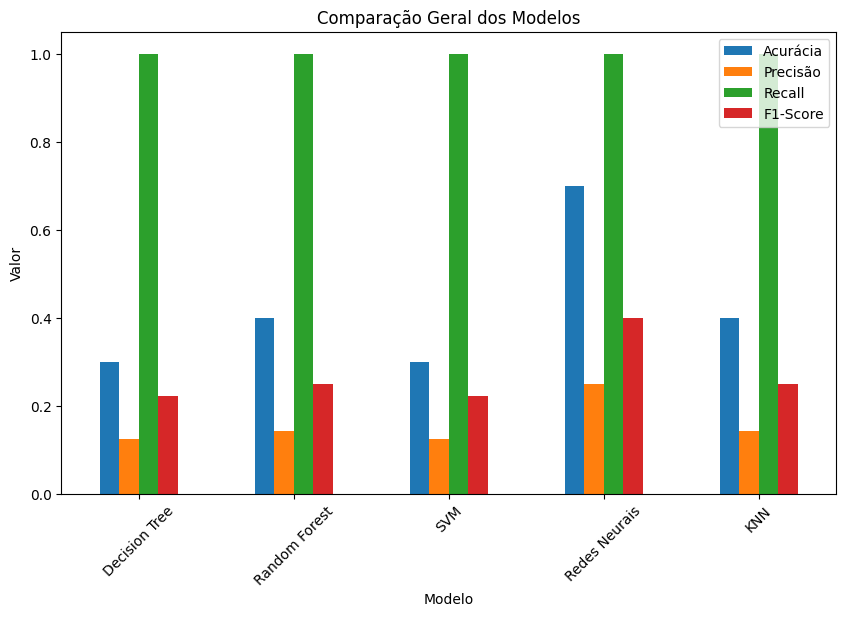

In [543]:
resultado_modelos.set_index('Modelo')[
    ['Acurácia', 'Precisão', 'Recall', 'F1-Score']
].plot(kind='bar', figsize=(10, 6))

plt.title('Comparação Geral dos Modelos')
plt.ylabel('Valor')
plt.xticks(rotation=45)
plt.show()

In [544]:
melhor_modelo = resultado_modelos.loc[
    resultado_modelos['F1-Score'].idxmax()
]

print("Melhor modelo:")
print(melhor_modelo)

Melhor modelo:
Modelo      Redes Neurais
Acurácia              0.7
Precisão             0.25
Recall                1.0
F1-Score              0.4
Name: 3, dtype: object


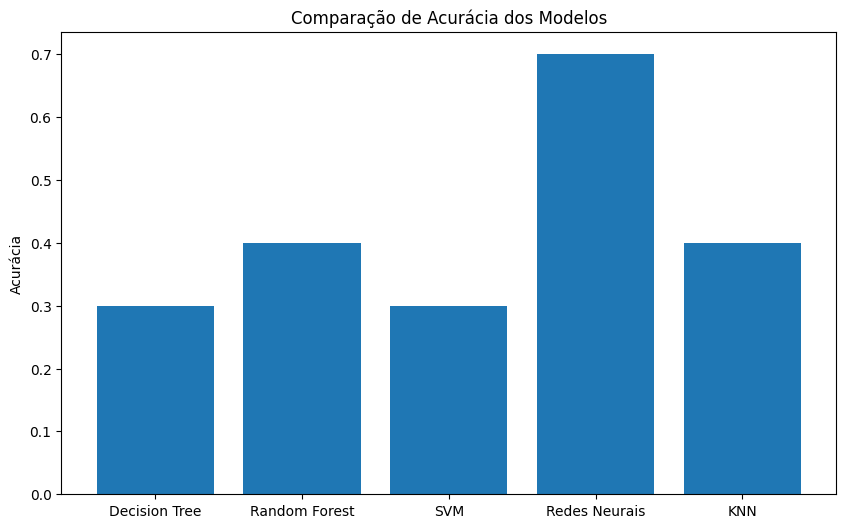

In [545]:
plt.figure(figsize=(10, 6))
plt.bar(resultado_modelos['Modelo'],
        resultado_modelos['Acurácia'])

plt.title('Comparação de Acurácia dos Modelos')
plt.ylabel('Acurácia')
plt.show()

# Pipeline 10 | Conclusões Analíticas

**Decision Tree:**
A Árvore de Decisão apresentou acurácia de 30% e F1-Score de 0,22. Apesar de ser um modelo de fácil interpretação, gerou muitos falsos positivos e teve dificuldade em generalizar os padrões da base IBM.

**Random Forest:**
O Random Forest obteve acurácia de 40% e F1-Score de 0,25. O método Ensemble melhorou ligeiramente os resultados da Árvore de Decisão, porém ainda apresentou dificuldades para prever corretamente as oscilações diárias das ações.

**SVM:**
O SVM alcançou acurácia de 30% e F1-Score de 0,22. O modelo identificou os casos positivos, mas não conseguiu separar adequadamente as classes, resultando em diversas classificações incorretas.

**KNN:**
O KNN apresentou acurácia de 40% e F1-Score de 0,25. Seu desempenho foi semelhante ao Random Forest, mostrando capacidade limitada para capturar os padrões presentes na série temporal analisada.

**Redes Neurais:**
A Rede Neural foi o modelo com melhor desempenho, alcançando 70% de acurácia e F1-Score de 0,40. O resultado sugere maior capacidade de identificar relações não lineares nos dados históricos da IBM.

**Veredito do Consultor:**
Entre os cinco algoritmos avaliados, a Rede Neural Artificial apresentou os melhores resultados nas métricas analisadas, destacando-se em acurácia e F1-Score. Dessa forma, ela é a principal recomendação para este cenário.

Entretanto, por se tratar de um modelo de caixa preta, suas previsões devem ser utilizadas como apoio à tomada de decisão e não como substituição da análise humana, especialmente em aplicações financeiras que envolvem riscos e impactos econômicos.